In [1]:
import networkx as nx
import itertools
import matplotlib.pyplot as plt
from b_chromatic_utils import *

### Function for checking if a colouring is proper

In [2]:
def is_proper(G, c):
    for u,v in G.edges():
        if((c[u] is not None and c[v] is not None) and (c[u] == c[v])):
            return False
    return True

### Function for checking if a set of 4 vertices are b-chromatic

In [53]:
def are_b_chromatic(G, c, node_sets):
    C = set(list((c.values())))
    for vi in node_sets:
        C_prime = set()
        for u in G.adj[vi]:
            C_prime.add(c[u])
        if C_prime != C.difference({c[vi]}):
            return False
    return True

## Force brute algorithm for finding a b-chromatic colouring on cubic graphs ($n<22$)

In [4]:
def find_b_chromatic_colouring_bruteforce(G, d):
    """Search for a b-chromatic colouring with d+1 colours on a d-regular graph G trying out all posible combination of colours
    G: d-regular graph
    d: integer
    """
    C = set([i for i in range(1,d+2)])
    S = list(itertools.combinations(G.nodes(),d+1))
    colour_permutations = [list(itertools.permutations(C.difference({i}))) for i in C]
    colour_prod_permutations = list(itertools.product(*colour_permutations))
    for node_sets in S:
        c = {u:None for u in G.nodes()}
        for i, vi in enumerate(node_sets): c[vi] = i+1
        for Xs in colour_prod_permutations:
            for i, vi in enumerate(node_sets):
                for j, uj in enumerate(G.adj[vi]):
                    if uj not in node_sets:
                        c[uj] = Xs[i][j]
            if is_proper(G, c) and are_b_chromatic(G, c, node_sets):
                print("b-chromatic vertices: {}".format(node_sets))
                return c
    return False

In [54]:
G = nx.random_regular_graph(3,8)
c = find_b_chromatic_colouring_bruteforce(G, 3)
c

b-chromatic vertices: (0, 1, 3, 5)


{0: 1, 1: 2, 2: 3, 4: 1, 3: 3, 7: 2, 6: 4, 5: 4}

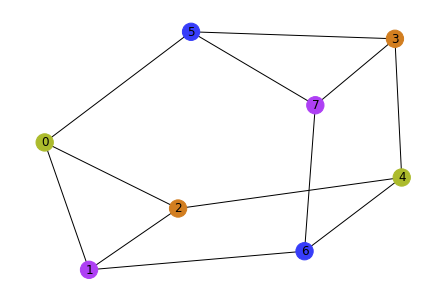

In [56]:
if c is not False:
    nx.draw(G, with_labels=True, node_color=get_colors_to_use(c))
else:
    nx.draw(G, with_labels=True)

## Algorithm for finding a b-chromatic colouring on cubic graphs ($n\geq 22$)

### Function for finding two vertices $u$ and $v$ such that $d(u,v)=4$

In [124]:
def bfs_dist_4(G, u):
    """Runs a BFS on G and return a BFS tree in form of adjacency list"""
    dist = {v:-1 for v in G.nodes()}
    tree = {v:[] for v in G.nodes()}
    dist[u] = 0
    Q = [u]
    while(len(Q) > 0):
        w = Q.pop(0)
        for v in G.adj[w]:
            if(dist[v] == -1):
                dist[v] = dist[w] + 1
                tree[w].append(v)
                Q.append(v)
    return tree

In [125]:
def dfs_path_4(tree, u):
    def dfs(tree, P, v):
        visited[v] = True
        P.append(v)
        for w in tree[v]:
            if not visited[w]:
                dfs(tree, P, w)
                if(len(P) == 5): break
                else: P.pop()# discard the last vertex added (which is w)

    visited = {v:False for v in tree.keys()}
    visited[u] = True
    P = []
    dfs(tree, P, u)
    return P

In [126]:
def get_path_length_4(G,u):
    tree = bfs_dist_4(G,u)
    P = dfs_path_4(tree, u)
    return P

In [145]:
G = nx.random_regular_graph(3, 24)
u = random.choice(list(G.nodes()))
P = get_path_length_4(G,u)
u, P

(4, [4, 20, 19, 16, 8])

In [146]:
colours = []
for w in G.nodes():
    if w in P:
        colours.append("#FF9933")
    #elif w in P_prime:
    #    colours.append("#AFB83B")
    else:
        colours.append("#96C3EB")

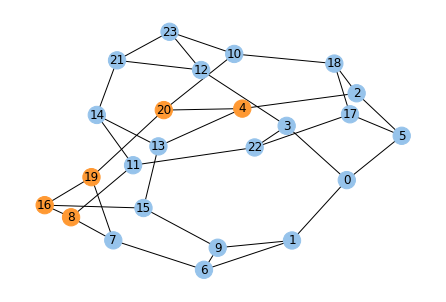

In [152]:
nx.draw(G, with_labels=True, node_color = colours)

### Function for making $u,w$ and $v$ b-chromatic vertices of colour 1, 2 and 3

In [197]:
def find_3_b_chromatic_vertices(G, P):
    """Receive a graph G and a path P=<u,u3,w,v3,v> such that dist(u,v)=4"""
    c = {u:None for u in G.nodes()}
    u, u3, w, v3, v = P[0], P[1], P[2], P[3], P[4]
    print(u,w,v)
    u1, u2 = tuple(set(G.adj[u]).difference({u3}))
    v1, v2 = tuple(set(G.adj[v]).difference({v3}))
    print(u1,u2)
    print(v1,v2)
    Pp = [u1,u2,v1,v2]
    c[u] = c[v3] = 1
    c[v] = c[u3] = 3 
    c[w] = c[u1] = c[v1] = 2
    c[u2] = c[v2] = 4
    wp = [x for x in G.adj[w] if x != u3 and x != v3][0]
    print(wp)
    if wp in Pp:
        print("w' in P'")
        if wp == u1: c[u1], c[u2] = c[u2], c[u1]
        elif wp == v1: c[v1], c[v2] = c[v2], c[v1]
    else:
        print(wp, u, v)
        S = {x for x in G.adj[wp] if x in Pp}
        print("S = {}".format(S))
        if len(S) == 0: c[wp] = 4
        elif len(S) == 1:
            
            # Assume S={x}
            x = S.pop()
            if x == u2: c[u1], c[x] = c[x], c[u1]
            if x == v2: c[v1], c[x] = c[x], c[v1]
            c[wp] = 4
        else:
            #Assume S={x,y}
            x, y = S.pop(), S.pop()
            #x in N(u) and y in N(v)
            if x in G.adj[u] and y in G.adj[v]:
                if x == u2: c[u1], c[x] = c[x], c[u1]
                if y == v2: c[v1], c[y] = c[y], c[v1]
            elif x in G.adj[v] and y in G.adj[u]:
                if x == v2: c[v1], c[x] = c[x], c[v1]
                if y == u2: c[u1], c[y] = c[y], c[u1]
            elif x in G.adj[u] and y in G.adj[u]:
                c[v2], c[v3] = c[v3], c[u2]
                c[wp] = c[u2]
            elif x in G.adj[v] and y in G.adj[v]:
                c[u2], c[u3] = c[u3], c[v2]
                c[wp] = c[v2]
    Q = P+[u1,u2,v1,v2,wp]
    return c, Q


### Function for finding the 4th b-chromatic vertex

In [226]:
def find_b_chromatic_assignment(G, S, x, c):
    """ G: graph, S: {u,w,v}, x: vertex to check, c: colouring function, success: True when a b-chromatic assigment has been found"""
    C = list(itertools.permutations([1,2,3]))
    cp = c.copy()
    if cp[x] is None: cp[x] = 4
    T = {y for y in G.adj[x]}
    for colours in C:
        for i, xi in enumerate(T):
            if cp[x] is None or (cp[x] is not None and xi not in S and len(S.intersection(T)) == 0):
                cp[xi] = colours[i]
        if is_proper(G, cp) and are_b_chromatic(G, cp, {x}): return cp, True
    return c, False

In [177]:
def does_conditions_i_ii_lemma3_hold(G, c, x, CSNx, cNx):
    """Checks whether condition I and II of Lemma 3 hold on the uncoloured neighbours of x
    G: Graph
    c: colour function assigment
    x: candidate vertex to become b-chromatic
    SNx: Subset of neighbours of x with no colour assign to it (|CSNx| >= 2)
    cNx: Set of colour used in N(x)"""
    cCSNx = {xp: {c[xpp] for xpp in G.adj[xp] if xpp != x and c[xpp] is not None}for xp in CSNx}
    assert cCSNx != set()
    #print("u': c(N(u')) for u'in N(u): {}".format(cCSNx))
    #cNx = {c[xp] for xp in G.adj[x] if c[xp] is not None}
    I = set([1,2,3]).difference(cNx)
    #print(I)
    for xp in cCSNx.keys(): 
        I = I.intersection(cCSNx[xp])
        #print(I)
    
    if I != set(): return False
    #print("There is no colour in the intersection of cCSNx")
    for xp1, xp2 in itertools.combinations(CSNx, 2):
        #print(xp1,xp2)
        if (len(cCSNx[xp1].intersection(cCSNx[xp2])) == 2): return False
    return True

In [217]:
def can_u_become_b_chromatic(G, u, c):
    cNu = {c[up] for up in G.adj[u] if c[up] is not None} #colour set of the neighbour of u
    SNx = {up for up in G.adj[u] if c[up] is not None} #set of coloured neighbours of u
    #print("coloruhood of u: {} and coloured vertices in N(u): {}".format(cNu, SNx))
    if (cNu != set() and SNx != set()) and len(cNu) == len(SNx): return True
    if (cNu != set() and SNx != set()) and len(cNu) < len(SNx): return False
    CSNx = {up for up in G.adj[u] if up not in SNx}
    return does_conditions_i_ii_lemma3_hold(G, c, u, CSNx, cNu)


No!


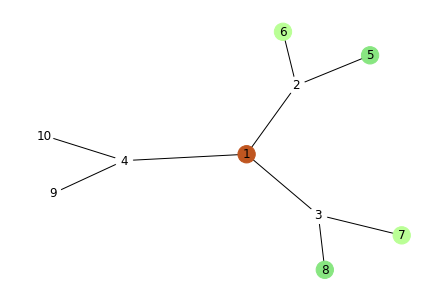

In [241]:
Gp = nx.Graph()
Gp.add_edges_from([(1,2),(1,3),(1,4),(2,5), (2,6), (3,7),(3,8), (4,9), (4,10)])
cp = {u:None for u in Gp.nodes()}
cp[1] = 4
#cp[2] = 1
#cp[3] = 3
#cp[4] = 2
cp[8] = cp[5] = 1
cp[6] = cp[7] = 2
#cp[10] = 1
if can_u_become_b_chromatic(Gp, 1, cp): print("Yes, it can!")
else: print("No!")
nx.draw(Gp, with_labels=True, node_color = get_colors_to_use(cp))

In [164]:
type({})

dict

In [229]:
def find_fourth_b_chromatic_vertex(G, x, c, visited, S, success):
    """G: Graph, x: vertex to check, c: colouring function, visited: verifies whether a vertex has been visited or not
    S: {u,w,v}, success: True when the fourth b-chromatic vertex has been found"""
    if not visited[x]:
        visited[x] = True
        print(x, list(G.adj[x]))
        cNx = {c[xp] for xp in G.adj[x] if c[xp] is not None}
        if (c[x] == 4 or (c[x] is None and 4 not in cNx)):
            if (c[x] == 4): print("{} has colour 4".format(x))
            else: print("{} is uncoloured and 4 is not in its neighbourhood".format(x))
            if (can_u_become_b_chromatic(G, x, c)):
                print("{} can become b-chromatic".format(x))
                c, success = find_b_chromatic_assignment(G, S, x, c)
                if success:
                    return c, success
            else:
                print("{} cannot become a b-chromatic vertex of colour 4".format(x))
        #print("c({}) is not colour 4 and  colour 4 is in its neighbourhood".format(x))
        for xp in G.adj[x]:
            if not visited[xp]:
                print(xp)
                c, success = find_fourth_b_chromatic_vertex(G, xp, c, visited, S, success)
                if success:
                    return c, success

In [185]:
G = nx.random_regular_graph(3, 24)
u = random.choice(list(G.nodes()))

21 7 16
0 5
17 6
19
19 21 16
{4, 5}


([21, 4, 7, 12, 16, 0, 5, 17, 6, 19], [21, 4, 7, 12, 16])

In [230]:
P = get_path_length_4(G, u)
c, Q = find_3_b_chromatic_vertices(G, P)
Q, P

21 7 16
0 5
17 6
19
19 21 16
S = {5}


([21, 4, 7, 12, 16, 0, 5, 17, 6, 19], [21, 4, 7, 12, 16])

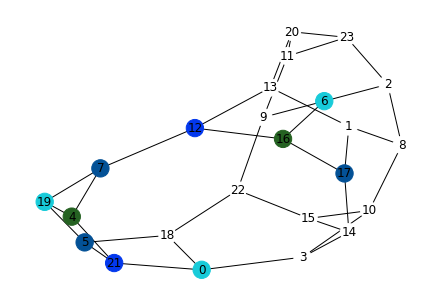

In [223]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(c))

In [231]:
visited = {x:False for x in G.nodes()}
S = {P[0], P[2], P[4]}
success = False
while not success:
    x = Q.pop()
    c, success = find_fourth_b_chromatic_vertex(G, x, c, visited, S, success)


19 [5, 7, 4]
19 has colour 4
19 cannot become a b-chromatic vertex of colour 4
5
5 [19, 18, 21]
18
18 [22, 5, 0]
22
22 [18, 9, 15]
22 is uncoloured and 4 is not in its neighbourhood
22 can become b-chromatic
9
9 [11, 22, 6]
11
11 [9, 23, 20]
11 is uncoloured and 4 is not in its neighbourhood
11 can become b-chromatic
23
23 [20, 11, 2]
23 is uncoloured and 4 is not in its neighbourhood
23 can become b-chromatic
20
20 [23, 11, 13]
20 is uncoloured and 4 is not in its neighbourhood
20 can become b-chromatic
13
13 [12, 20, 1]
13 is uncoloured and 4 is not in its neighbourhood
13 can become b-chromatic
12
12 [16, 13, 7]
16
16 [12, 6, 17]
6
6 [16, 2, 9]
6 has colour 4
6 can become b-chromatic
2
2 [8, 23, 6]
8
8 [2, 1, 10]
8 is uncoloured and 4 is not in its neighbourhood
8 can become b-chromatic
1
1 [8, 17, 13]
1 is uncoloured and 4 is not in its neighbourhood
1 can become b-chromatic
17
17 [1, 14, 16]
14
14 [15, 3, 17]
14 is uncoloured and 4 is not in its neighbourhood
14 can become b-chrom

TypeError: cannot unpack non-iterable NoneType object

In [ ]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(c))

In [ ]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(c))

In [ ]:
list(Q)

## Analyzing 4-regular graph with diam $(G)\leq 2$

In [238]:
diam_k = False
d = 3
while(not diam_k):
    n = 8
    Gp = nx.random_regular_graph(4, n)
    if nx.diameter(Gp) == d: diam_k = True

KeyboardInterrupt: 

In [237]:
cp = find_b_chromatic_colouring_bruteforce(Gp, 4)

KeyboardInterrupt: 

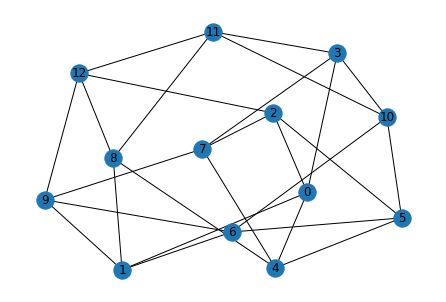

In [235]:
nx.draw(Gp, with_labels=True)

In [ ]:
n = random.randint(5, 22)
n